# Formula 1 World Championship (1950 - 2024) analysis

### Team victory by decade

/var/folders/4d/sy9ttl7x5115lb6xjj0n20rc0000gn/T/ipykernel_35690/3203980931.py:4: DtypeWarning: Columns (0: fastest_lap_time, 1: quali_q2, 2: quali_q3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("mainDataset.csv")


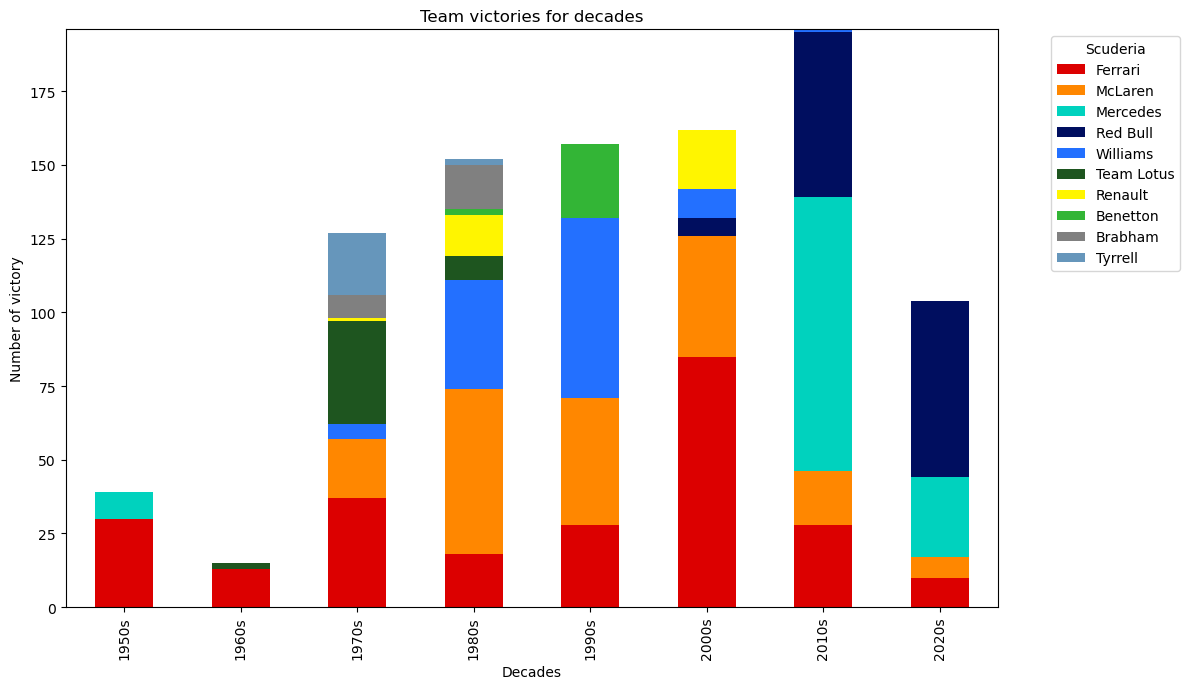

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("mainDataset.csv")

winners = df[df["finish_position"] == 1].copy()

winners["decade"] = (winners["year"] // 10) * 10

wins_by_decade = winners.groupby(["decade", "constructor_name"]).size().unstack(fill_value=0)

top_teams = wins_by_decade.sum().sort_values(ascending=False).head(10).index
wins_by_decade = wins_by_decade[top_teams]

wins_by_decade.index = [f"{d}s" for d in wins_by_decade.index]

colors = {
    "Ferrari": "#DC0000",      # rosso Ferrari
    "Red Bull": "#000E5F",     # blu Red Bull
    "Mercedes": "#00D2BE",     # azzurro Mercedes
    "Renault": "#FFF500",      # giallo Renault
    "Williams": "#2370FF",     # blu Williams (diverso!)
    "McLaren": "#FF8700",
    "Team Lotus": "#1E551F",
    "Benetton": "#33B536",
    "Brabham": "gray",
    "Tyrrell": "#6696BB"
}

default_colors = plt.cm.tab20.colors
color_list = []

for i, team in enumerate(wins_by_decade.columns):
    if team in colors:
        color_list.append(colors[team])
    else:
        color_list.append(default_colors[i % len(default_colors)])

wins_by_decade.plot(kind="bar", stacked=True, figsize=(12,7), color=color_list)

plt.xlabel("Decades")
plt.ylabel("Number of victory")
plt.title("Team victories for decades")

plt.legend(title="Scuderia", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.show()

### Fastest circuits

/var/folders/4d/sy9ttl7x5115lb6xjj0n20rc0000gn/T/ipykernel_34458/2140369155.py:5: DtypeWarning: Columns (0: fastest_lap_time, 1: quali_q2, 2: quali_q3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("mainDataset.csv")


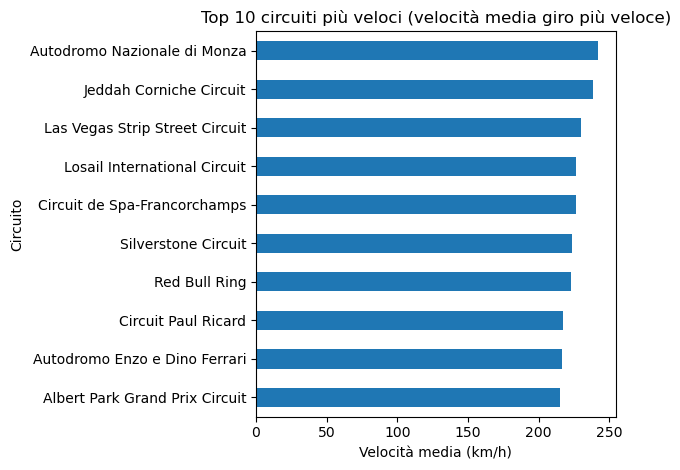

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Carica il dataset (modifica il percorso se serve)
df = pd.read_csv("mainDataset.csv")

# Pulizia base: rimuove valori mancanti
df = df.dropna(subset=["circuit_name", "fastest_lap_speed_kmh"])

# Calcola la velocità media per circuito
fastest_circuits = (
    df.groupby("circuit_name")["fastest_lap_speed_kmh"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

# Plot
plt.figure()
fastest_circuits.sort_values().plot(kind="barh")

plt.title("Top 10 circuiti più veloci (velocità media giro più veloce)")
plt.xlabel("Velocità media (km/h)")
plt.ylabel("Circuito")

plt.tight_layout()
plt.show()

### Fastest lap evolution

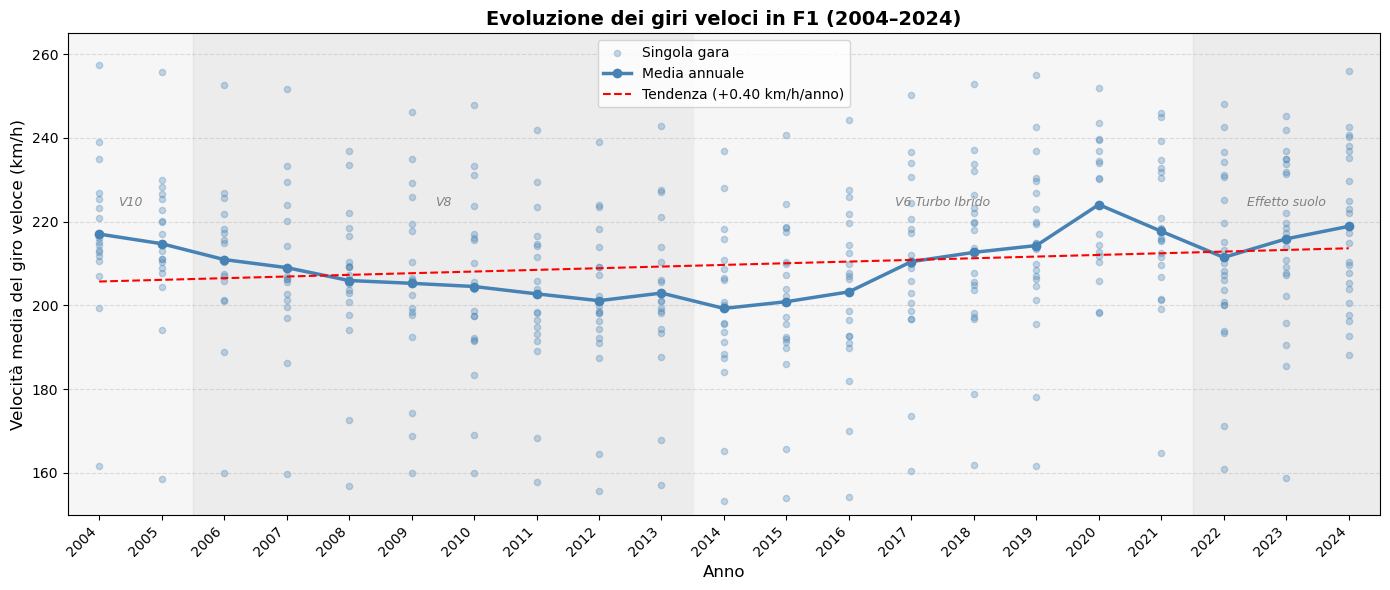

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Caricamento dati ---
df = pd.read_csv("mainDataset.csv", low_memory=False)

# Teniamo solo il giro veloce ufficiale di ogni gara (rank 1)
df = df[df["fastest_lap_rank"] == 1].dropna(subset=["fastest_lap_speed_kmh", "year"])
df["year"] = df["year"].astype(int)

# Media della velocità del giro veloce per anno
yearly_mean = df.groupby("year")["fastest_lap_speed_kmh"].mean()

# --- Linea di tendenza lineare (regressione di primo grado) ---
x = yearly_mean.index.values
y = yearly_mean.values
coeffs = np.polyfit(x, y, 1)        # coeffs[0] = pendenza, coeffs[1] = intercetta
trend = np.poly1d(coeffs)

# --- Ere regolamentari (sfondo del grafico) ---
eras = [
    (2004, 2005, "V10"),
    (2006, 2013, "V8"),
    (2014, 2021, "V6 Turbo Ibrido"),
    (2022, 2024, "Effetto suolo"),
]

# --- Grafico ---
fig, ax = plt.subplots(figsize=(14, 6))

# Sfondo per ogni era (colori alternati grigi chiari)
era_colors = ["#f0f0f0", "#e0e0e0", "#f0f0f0", "#e0e0e0"]
for (start, end, label), color in zip(eras, era_colors):
    ax.axvspan(start - 0.5, end + 0.5, color=color, alpha=0.6)
    ax.text((start + end) / 2, 223, label,
            ha="center", va="bottom", fontsize=9, color="gray", style="italic")

# Scatter: velocità di ogni singola gara
ax.scatter(df["year"], df["fastest_lap_speed_kmh"],
           color="steelblue", alpha=0.3, s=20, label="Singola gara")

# Linea della media annuale
ax.plot(yearly_mean.index, yearly_mean.values,
        color="steelblue", linewidth=2.5, marker="o", markersize=6,
        label="Media annuale")

# Linea di tendenza
ax.plot(x, trend(x),
        color="red", linewidth=1.5, linestyle="--",
        label=f"Tendenza ({coeffs[0]:+.2f} km/h/anno)")

# --- Etichette e titolo ---
ax.set_xlabel("Anno", fontsize=12)
ax.set_ylabel("Velocità media del giro veloce (km/h)", fontsize=12)
ax.set_title("Evoluzione dei giri veloci in F1 (2004–2024)", fontsize=14, fontweight="bold")

ax.set_xlim(2003.5, 2024.5)
ax.set_xticks(range(2004, 2025))
ax.set_xticklabels(range(2004, 2025), rotation=45, ha="right")
ax.set_ylim(150, 265)

ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(fontsize=10)


# Print graphic
plt.tight_layout()
plt.savefig("FastlapEvolution.png", dpi=150, bbox_inches="tight")
plt.show()

### Pitstops by year

/var/folders/4d/sy9ttl7x5115lb6xjj0n20rc0000gn/T/ipykernel_34458/4096950641.py:5: DtypeWarning: Columns (0: fastest_lap_time, 1: quali_q2, 2: quali_q3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("mainDataset.csv")


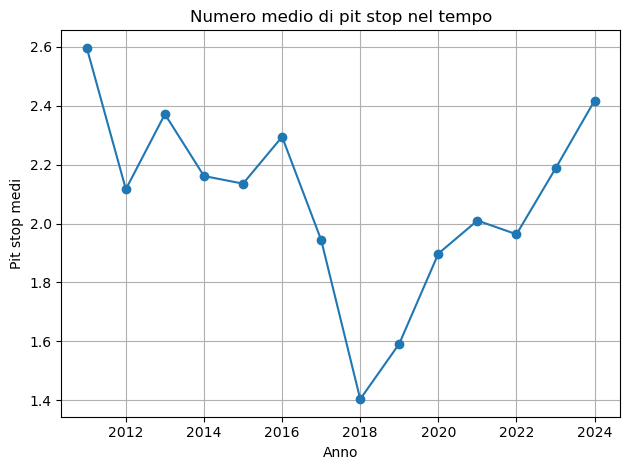

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Carica il dataset
df = pd.read_csv("mainDataset.csv")

# Pulizia: rimuove valori mancanti
df = df.dropna(subset=["year", "pit_stop_count"])

# Calcola media pit stop per anno
pitstop_trend = (
    df.groupby("year")["pit_stop_count"]
    .mean()
    .sort_index()
)

# Grafico
plt.figure()
pitstop_trend.plot(marker='o')

plt.title("Numero medio di pit stop nel tempo")
plt.xlabel("Anno")
plt.ylabel("Pit stop medi")

plt.grid(True)
plt.tight_layout()
plt.show()

---

### Relation between qualify result and race result

/var/folders/4d/sy9ttl7x5115lb6xjj0n20rc0000gn/T/ipykernel_34458/3089263834.py:6: DtypeWarning: Columns (0: fastest_lap_time, 1: quali_q2, 2: quali_q3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("mainDataset.csv")


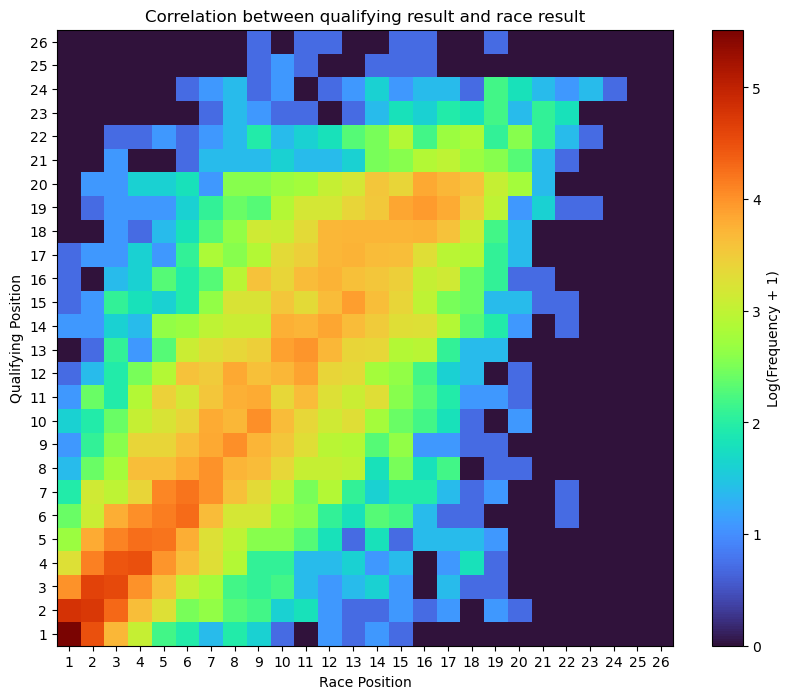

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


df = pd.read_csv("mainDataset.csv")

df = df[['quali_position', 'finish_position']].dropna()

df['quali_position'] = pd.to_numeric(df['quali_position'], errors='coerce')
df['finish_position'] = pd.to_numeric(df['finish_position'], errors='coerce')

df = df.dropna()

df = df[(df['quali_position'] >= 1) & (df['quali_position'] <= 30)]
df = df[(df['finish_position'] >= 1) & (df['finish_position'] <= 30)]

heatmap = pd.crosstab(df['quali_position'], df['finish_position'])

heatmap = heatmap.reindex(index=range(1,27), columns=range(1,27), fill_value=0)

data = np.log1p(heatmap)

# Plot
plt.figure(figsize=(10,8))
plt.imshow(data, cmap='turbo', origin='lower')  # <-- asse y parte dal basso

# Assi
plt.xticks(range(26), range(1,27))
plt.yticks(range(26), range(1,27))

plt.xlabel("Race Position")
plt.ylabel("Qualifying Position")
plt.title("Correlation between qualifying result and race result")

# (Opzionale ma consigliato) barra colori
plt.colorbar(label='Log(Frequency + 1)')

plt.show()

---

### Countries with most F1 Races

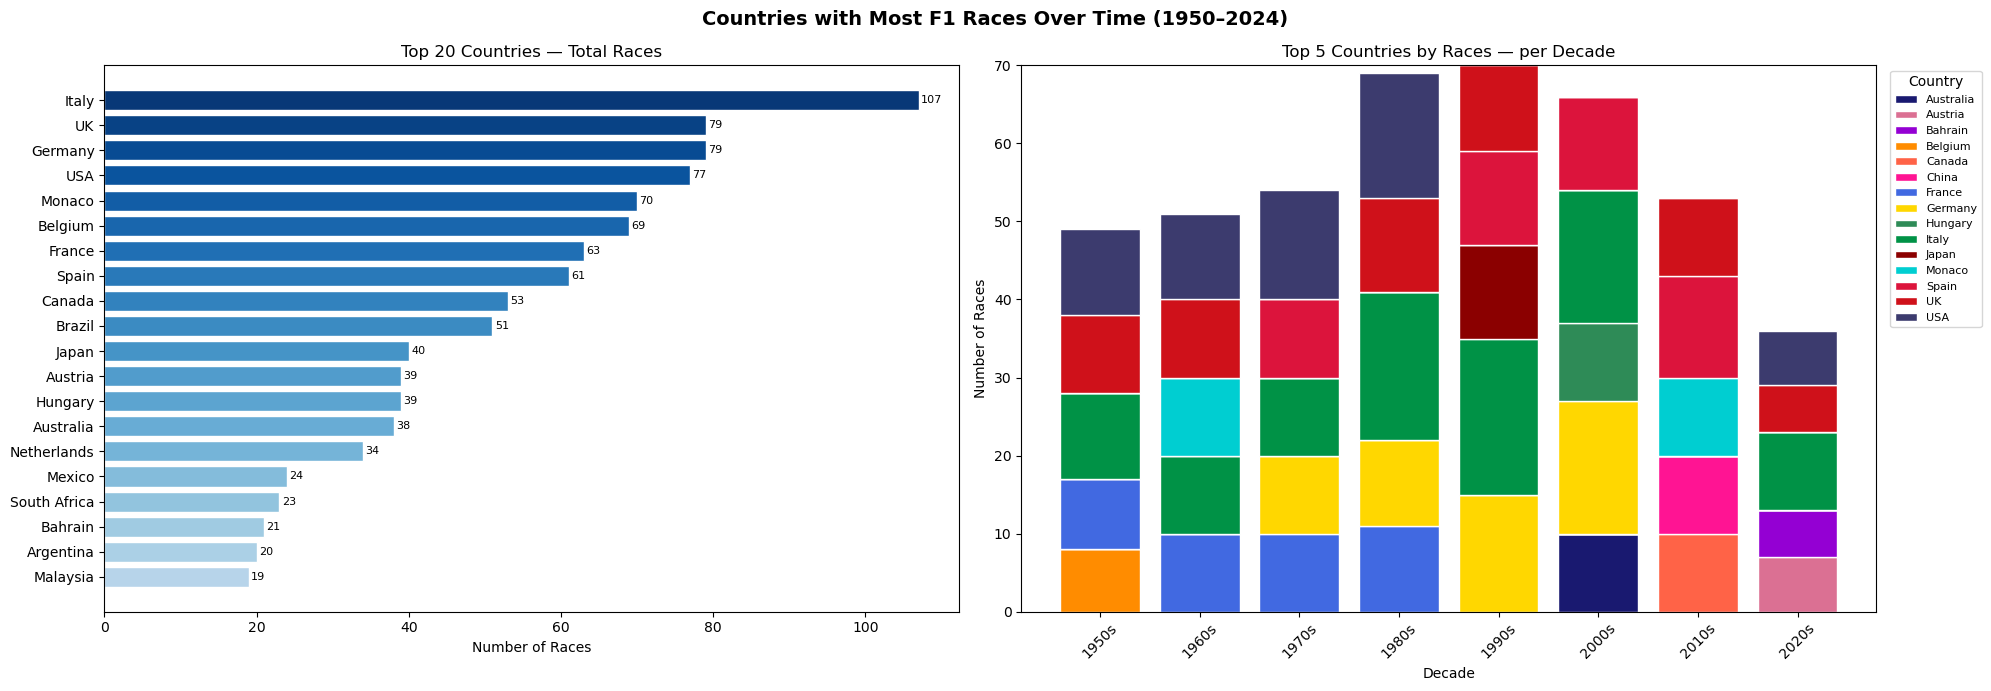

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("mainDataset.csv", low_memory=False)
gare_uniche = df.drop_duplicates(subset="raceId")[["raceId", "country", "year"]]

races_per_country = (
    gare_uniche.groupby("country").size()
    .reset_index(name="n_races")
    .sort_values("n_races", ascending=False)
)

gare_uniche["decade"] = (gare_uniche["year"] // 10 * 10).astype(str) + "s"

races_per_decade = (
    gare_uniche.groupby(["country", "decade"]).size()
    .reset_index(name="n_races")
)

top5_per_decade = (
    races_per_decade.sort_values("n_races", ascending=False)
    .groupby("decade")
    .head(5)
)

pivot = (
    top5_per_decade.pivot(index="decade", columns="country", values="n_races")
    .fillna(0)
)

FLAG_COLORS = {
    "Italy":        "#009246",
    "Germany":      "#FFD700",
    "UK":           "#CF111A",
    "USA":          "#3C3B6E",
    "Monaco":       "#00CED1",
    "Belgium":      "#FF8C00",
    "France":       "#4169E1",
    "Spain":        "#DC143C",
    "Canada":       "#FF6347",
    "Brazil":       "#228B22",
    "Japan":        "#8B0000",
    "Austria":      "#DB7093",
    "Hungary":      "#2E8B57",
    "Australia":    "#191970",
    "Netherlands":  "#FF4500",
    "Mexico":       "#556B2F",
    "South Africa": "#DAA520",
    "Bahrain":      "#9400D3",
    "Argentina":    "#87CEEB",
    "Malaysia":     "#8B4513",
    "Switzerland":  "#A9A9A9",
    "Sweden":       "#4682B4",
    "Portugal":     "#006400",
    "China":        "#FF1493",
}

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle("Countries with Most F1 Races Over Time (1950–2024)", fontsize=14, fontweight="bold")

# --- Chart 1: Top 20 total, all blue ---
top20 = races_per_country.head(20)
blues = plt.cm.Blues([0.3 + 0.7 * i / len(top20) for i in range(len(top20))])
bars = axes[0].barh(top20["country"][::-1], top20["n_races"][::-1], color=blues, edgecolor="white")
axes[0].set_title("Top 20 Countries — Total Races")
axes[0].set_xlabel("Number of Races")
for bar, val in zip(bars, top20["n_races"][::-1]):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                 str(val), va="center", fontsize=8)

# --- Chart 2: Top 5 per decade ---
decades = sorted(pivot.index.tolist())
bottom = np.zeros(len(decades))
x = np.arange(len(decades))

for country in pivot.columns:
    values = [pivot.loc[d, country] if d in pivot.index else 0 for d in decades]
    if sum(values) == 0:
        continue
    color = FLAG_COLORS.get(country, "#AAAAAA")
    axes[1].bar(x, values, bottom=bottom, label=country, color=color, edgecolor="white")
    bottom += np.array(values)

axes[1].set_title("Top 5 Countries by Races — per Decade")
axes[1].set_xlabel("Decade")
axes[1].set_ylabel("Number of Races")
axes[1].set_xticks(x)
axes[1].set_xticklabels(decades, rotation=45)
axes[1].legend(title="Country", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.savefig("races_per_country.png", dpi=150)
plt.show()